<a href="https://colab.research.google.com/github/2d-game-dev/computer-vision/blob/main/CIFAR_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import copy



In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [19]:
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [20]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

classes = train_dataset.classes

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

In [21]:
param_grid = [
    {"lr":0.001,  "dropout":0.3},
    {"lr":0.0005, "dropout":0.4},
    {"lr":0.0003, "dropout":0.4},
]

batch_size = 64
weight_decay = 1e-4

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

search_results = []

In [22]:
def create_model(dropout):
    model = models.resnet18(weights="DEFAULT")

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, 10)
    )

    return model.to(device)


In [23]:
print("\n===== Hyperparameter Search Started =====")

for params in param_grid:

    print(f"\nTesting LR={params['lr']} | Dropout={params['dropout']}")

    model = create_model(params["dropout"])

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=weight_decay
    )

    # quick search only 2 epochs
    for epoch in range(2):

        model.train()

        for images, labels in tqdm(train_loader, leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # validation score
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs,1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    val_acc = 100 * correct / total

    print("Validation Accuracy:", round(val_acc,2))

    search_results.append({
        "lr": params["lr"],
        "dropout": params["dropout"],
        "val_acc": val_acc
    })

# choose best
best_params = max(search_results, key=lambda x: x["val_acc"])

print("\n===== BEST HYPERPARAMETERS =====")
print(best_params)


===== Hyperparameter Search Started =====

Testing LR=0.001 | Dropout=0.3


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

Validation Accuracy: 89.9

Testing LR=0.0005 | Dropout=0.4


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

Validation Accuracy: 90.65

Testing LR=0.0003 | Dropout=0.4


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

Validation Accuracy: 91.61

===== BEST HYPERPARAMETERS =====
{'lr': 0.0003, 'dropout': 0.4, 'val_acc': 91.61}


In [26]:
best_lr = best_params["lr"]
best_dropout = best_params["dropout"]

model = create_model(best_dropout)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=best_lr,
    weight_decay=weight_decay
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

epochs = 15
train_losses = []
val_losses = []
best_acc = 0

print("\n===== Final Training Started =====")

for epoch in range(epochs):

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    # Training
    model.train()
    running_loss = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    #validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, pred = torch.max(outputs,1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    acc = 100 * correct / total

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(),"best_model.pth")
        print("Best model saved!")

print("\nTraining Finished!")
print("Best Validation Accuracy:", round(best_acc,2), "%")



===== Final Training Started =====

Epoch [1/15]


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.4357
Val Loss:   0.2773
Val Acc:    90.55%
Best model saved!

Epoch [2/15]


Training:   0%|          | 0/625 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.0301
Val Loss:   0.2347
Val Acc:    93.56%

Epoch [15/15]


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.0268
Val Loss:   0.2325
Val Acc:    93.47%

Training Finished!
Best Validation Accuracy: 94.2 %


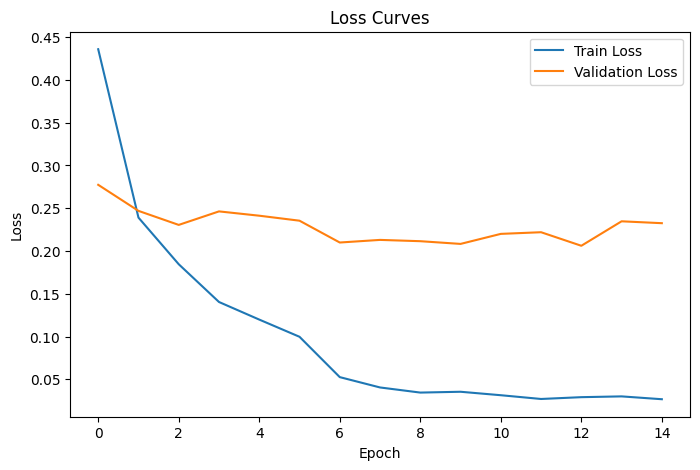

In [27]:
plt.figure(figsize=(8,5))
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [28]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, pred = torch.max(outputs,1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total

print("\nTest Accuracy:", round(test_acc,2), "%")
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))


  0%|          | 0/157 [00:00<?, ?it/s]


Test Accuracy: 93.03 %

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1000
           1       0.96      0.96      0.96      1000
           2       0.94      0.90      0.92      1000
           3       0.84      0.86      0.85      1000
           4       0.93      0.92      0.92      1000
           5       0.90      0.86      0.88      1000
           6       0.93      0.97      0.95      1000
           7       0.97      0.94      0.95      1000
           8       0.95      0.96      0.96      1000
           9       0.97      0.94      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [33]:
print("\n" + "="*50)
print("BENCHMARK COMPARISON")
print("="*50)

# Known benchmarks for ResNet18 on CIFAR-10
benchmark_low = 93.0
benchmark_high = 95.0

print(f"Your Test Accuracy: {test_acc:.2f}%")
print(f"ResNet18 Benchmark Range: {benchmark_low}-{benchmark_high}%")
print(f"Source: PapersWithCode / Original ResNet paper")

if test_acc >= benchmark_low:
    print(f"✅ SUCCESS: Your model meets or exceeds the benchmark!")
else:
    print(f"⚠️ Below benchmark by {benchmark_low - test_acc:.2f}%")



BENCHMARK COMPARISON
Your Test Accuracy: 93.03%
ResNet18 Benchmark Range: 93.0-95.0%
Source: PapersWithCode / Original ResNet paper
✅ SUCCESS: Your model meets or exceeds the benchmark!


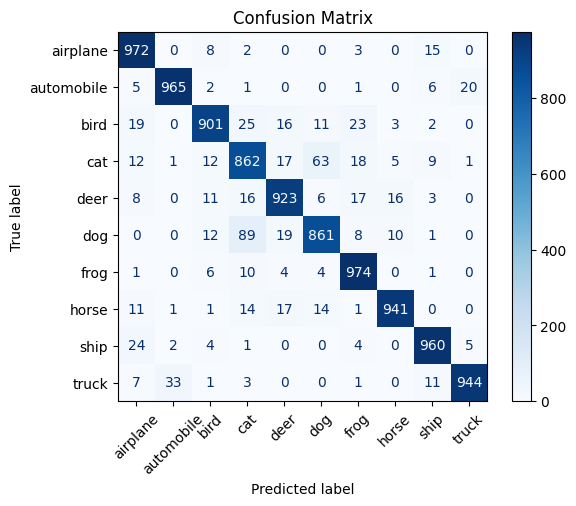

In [29]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [30]:
print("\nSingle Image Inference Example")

img, label = test_dataset[0]

with torch.no_grad():
    output = model(img.unsqueeze(0).to(device))
    pred = torch.argmax(output,1).item()

print("Real Label:", classes[label])
print("Predicted :", classes[pred])


Single Image Inference Example
Real Label: cat
Predicted : cat
